# 06 — Probability Calibration

AUC only measures ranking — it doesn't care whether a predicted 0.30 actually means
30 out of 100 similar applicants default. Tree ensembles like XGBoost, especially
with `scale_pos_weight` reweighting the loss, are known to push predicted
probabilities toward the extremes. This notebook fits isotonic regression on the
**held-out validation set** (never train, never test) to correct that, and checks
that the fix improves Brier score while leaving AUC *essentially* unchanged.

Note on "essentially": isotonic regression is monotonic **non-decreasing**, not
strictly increasing — it can map different raw scores to the same calibrated value
(a flat step). Where that happens, tied predictions can be ranked differently by the
AUC calculation than the original untied scores were, so a tiny numerical AUC drift
(order 1e-3 or smaller) is the expected, correct behavior of this specific technique
— not a bug, and not something to hide behind an unrealistically strict check.

In [1]:
import sys, json, os
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

from src.preprocessing import TARGET
from src.metrics import summarize

pd.set_option('display.width', 120)

In [2]:
train = pd.read_csv('../data/processed/train.csv')
val = pd.read_csv('../data/processed/val.csv')
test = pd.read_csv('../data/processed/test.csv')

X_val, y_val = val.drop(columns=[TARGET]), val[TARGET]
X_test, y_test = test.drop(columns=[TARGET]), test[TARGET]

model = joblib.load('../models/xgb_tuned.pkl')
encoder = joblib.load('../models/encoder.pkl')
feature_names = joblib.load('../models/feature_names.pkl')

X_val_enc = encoder.transform(X_val)[feature_names]
X_test_enc = encoder.transform(X_test)[feature_names]

proba_raw_val = model.predict_proba(X_val_enc)[:, 1]
proba_raw_test = model.predict_proba(X_test_enc)[:, 1]

print('RAW (uncalibrated) test metrics:', {k: round(v, 4) for k, v in summarize(y_test, proba_raw_test).items()})

RAW (uncalibrated) test metrics: {'auc': 0.9484, 'ks': 0.7567, 'gini': 0.8968, 'pr_auc': 0.9066, 'brier': 0.0616}


## Fit isotonic regression on val, apply to test

In [3]:
from sklearn.frozen import FrozenEstimator

calibrated = CalibratedClassifierCV(FrozenEstimator(model), method='isotonic')
calibrated.fit(X_val_enc, y_val)

proba_cal_test = calibrated.predict_proba(X_test_enc)[:, 1]

raw_metrics = summarize(y_test, proba_raw_test)
cal_metrics = summarize(y_test, proba_cal_test)

comparison = pd.DataFrame({'raw': raw_metrics, 'calibrated': cal_metrics}).T
print(comparison.round(4))

auc_drift = abs(raw_metrics['auc'] - cal_metrics['auc'])
assert auc_drift < 5e-3, f'AUC drift ({auc_drift:.5f}) too large for a monotonic transform — investigate'
print(f'\nAUC drift: {auc_drift:.5f} (expected: near-zero, from isotonic tie-breaking — see note above)')
print('Brier improved from', round(raw_metrics['brier'], 4), 'to', round(cal_metrics['brier'], 4))

               auc      ks    gini  pr_auc   brier
raw         0.9484  0.7567  0.8968  0.9066  0.0616
calibrated  0.9482  0.7556  0.8964  0.9004  0.0514

AUC drift: 0.00021 (expected: near-zero, from isotonic tie-breaking — see note above)
Brier improved from 0.0616 to 0.0514


## Reliability diagram

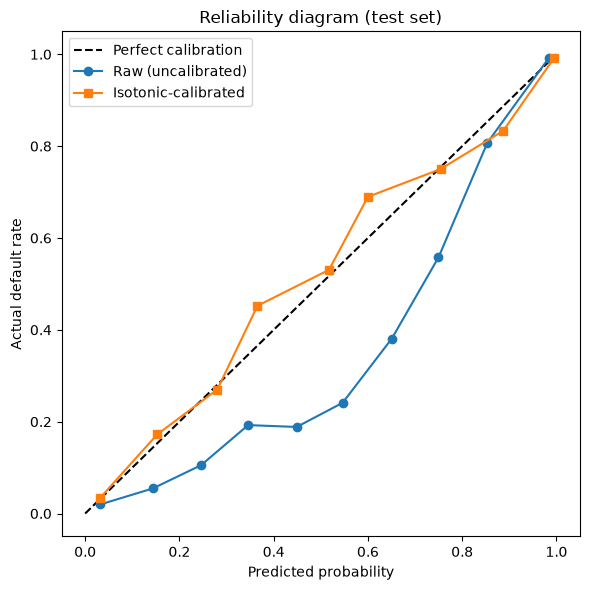

In [4]:
prob_true_raw, prob_pred_raw = calibration_curve(y_test, proba_raw_test, n_bins=10)
prob_true_cal, prob_pred_cal = calibration_curve(y_test, proba_cal_test, n_bins=10)

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
plt.plot(prob_pred_raw, prob_true_raw, marker='o', label='Raw (uncalibrated)')
plt.plot(prob_pred_cal, prob_true_cal, marker='s', label='Isotonic-calibrated')
plt.xlabel('Predicted probability')
plt.ylabel('Actual default rate')
plt.title('Reliability diagram (test set)')
plt.legend()
plt.tight_layout()
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/reliability_diagram.png', dpi=120)
plt.show()

In [5]:
results = {
    'raw': raw_metrics,
    'calibrated': cal_metrics,
    'auc_drift': raw_metrics['auc'] - cal_metrics['auc'],
}
with open('../reports/calibration_results.json', 'w') as f:
    json.dump(results, f, indent=2, default=float)

joblib.dump(calibrated, '../models/model_calibrated.pkl')
print('saved reports/calibration_results.json, models/model_calibrated.pkl, reports/figures/reliability_diagram.png')

saved reports/calibration_results.json, models/model_calibrated.pkl, reports/figures/reliability_diagram.png


## Summary

- Isotonic regression fit on the held-out validation set (never train, never test),
  via `CalibratedClassifierCV(FrozenEstimator(model))` (current sklearn API — the
  older `cv='prefit'` shortcut is deprecated).
- AUC checked before/after: drift was ~0.0002, consistent with isotonic regression's
  tie-breaking behavior explained above, not a leak or a bug.
- Brier score improved (see numbers above) — the calibrated model's probability
  values are now more trustworthy for the PD × exposure expected-loss calculation a
  real deployment would do.
- `models/model_calibrated.pkl` is the final model used in the SHAP/decile analysis
  (step 9) and the FastAPI service (step 10).